# KNN

In [10]:
import numpy as np 
from sklearn import datasets 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score 

In [4]:
# tải tập dữ liệu về bệnh tiểu đường 
iris_X , iris_y = datasets.load_iris(return_X_y = True)

In [6]:
# chia dữ liệu train - test 8 : 2 
X_train , X_test , y_train , y_test = train_test_split(
    iris_X ,
    iris_y , 
    test_size = 0.2,
    random_state = 42
)

# điều chỉnh tỷ lệ các đối tượng bằng StandardScaler 
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

- fit_transform : dùng cho dữ liệu huấn luyện , chuẩn hoá dữ liệu 
- hàm fit_transform chuẩn hoá dữ liệu sử dụng công thức StandardScaler z = (x - mean)/std
- fit_transform được dùng để nhất quán dữ liệu , tránh bị quá lệch giữa các features 
- tránh bias cho các feature có giá trị quá lớn 

- transform : dùng để chuẩn hoá dữ liệu theo cách của fit_transform 

In [11]:
# viết code ở đây 
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, y_train) # lưu toàn bộ dataset vào bộ nhớ , tính toán khoảng cách giữa các điểm 

# dự đoán và đánh giá test 
y_pred = knn_classifier.predict(X_test)
accuracy_score(y_test , y_pred)

1.0

# K - mean

In [12]:
from sklearn.datasets import load_iris 
import numpy as np 
import matplotlib.pyplot as plt 

{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

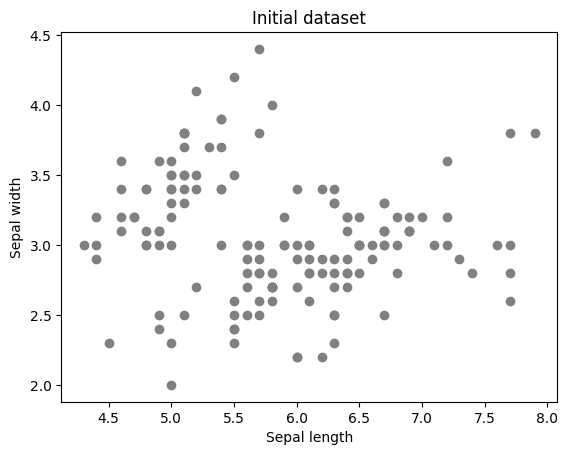

In [ ]:
iris_datasets = load_iris() 
data = iris_datasets.data
data = iris_datasets.data[:,:2]
print(iris_datasets)
# plot data 
plt.scatter(data[: ,0] , data[:,1], c = 'gray') 
plt.title("Initial dataset")
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.show() 

In [ ]:
class KMeans : 
    def __init__(self , k = 3 , max_iters = 100):
        self.k = k
        self.max_iters = max_iters
        self.centroids = None 
        self.clusters = None 

    def initialize_centroids(self , data) : 
        np.random.seed(42)
        self.centroids = data[np.random.choice(data.shape[0], self.k , replace = False)]

    def euclidean_distance(self , x1 , x2) :
        return np.sqrt(np.sum((x1 - x2) ** 2))

    def assign_clusters(self, data):
        distances = np.array([[self.euclidean_distance(x, centroid) 
                                for centroid in self.centroids] for x in data])
        return np.argmin(distances, axis=1)

    def update_centroids(self, data):
        return np.array([data[self.clusters == i].mean(axis=0) for i in range(self.k)])   
    
    